In [ ]:
import matplotlib.pyplot as plt
from matplotlib import font_manager

font_path = "Arial.ttf"

# 手动添加字体
font_manager.fontManager.addfont(font_path)

# 设置 matplotlib 使用 Arial
plt.rcParams['font.family'] = 'Arial'


In [4]:
%matplotlib inline

import os
import numpy as np
import sys
import pickle
import pandas as pd
import seaborn as sns 
import matplotlib.pyplot as plt
from tqdm import tqdm
from Levenshtein import distance
import json


In [5]:
pickle_path = "./model_bench_illumina.pkl"

with open(pickle_path, "rb") as f:
    ont_ret_dict = pickle.load(f)

In [6]:


rows = []
runtime_rows = []

# 内部分析键 -> 写入 stat_df 的 method 列（展示名）
method_to_key = {
     'new'   : 'SeqFormer',
    "new_noqual": "SeqFormer_noq",
    'bs'    : 'BSAlign',
    'poa'   : 'POA',
    'bmala' : 'BMALA',
    'itr'   : 'Iterative majority',
    'hybrid': 'Hybrid',
    'divbma': 'DivBMA',
}
# 与上键一一对应：output[item] 里取编辑距离的字段名
method_pickle_field = {
     'new'   : 'new_dis',
    "new_noqual": "seqformer_noqual_dis",
    'bs'    : 'bs_dis',
    'poa'   : 'poa_dis',
    'bmala' : 'bmala_dis',
    'itr'   : 'itr_dis',
    'hybrid': 'hybrid_dis',
    'divbma': 'divbma_dis',
}

for record_idx, (batched_data, output, runtime_data) in enumerate(ont_ret_dict):
    runtime_row = {"record": record_idx}
    runtime_row.update(runtime_data)
    runtime_rows.append(runtime_row)

    for depth_id, item in output.items():
        depth = int(depth_id[1:])
        for internal_key, method_label in method_to_key.items():
            dist_val = item.get(method_pickle_field[internal_key], None)
            if dist_val is None:
                continue
            rows.append(
                {
                    "record": record_idx,
                    "depth": depth,
                    "method": method_label,
                    "distance": dist_val,
                    "exact_match": int(dist_val == 0),
                }
            )

stat_df = pd.DataFrame(rows)
runtime_df = pd.DataFrame(runtime_rows)



In [7]:
result_df = (
    stat_df.groupby(["method", "depth"])
    .agg(
        cluster_count=("record", "count"),
        zero_distance_count=("exact_match", "sum"),
        sum_distance=("distance", "sum"),
    )
    .reset_index()
)
result_df["success_rate"] = (
    result_df["zero_distance_count"] / result_df["cluster_count"]
)
result_df["mean_distance"] = (
    result_df["sum_distance"] / result_df["cluster_count"]
)
result_df=result_df[result_df['depth'].between(3, 10)]

In [8]:
import matplotlib.pyplot as plt
from matplotlib import font_manager

font_path = "/data03/wangkun_data/Arial.ttf"

# 手动添加字体
font_manager.fontManager.addfont(font_path)

# 设置 matplotlib 使用 Arial
plt.rcParams['font.family'] = 'Arial'

print("已成功注册 Arial 字体")


已成功注册 Arial 字体


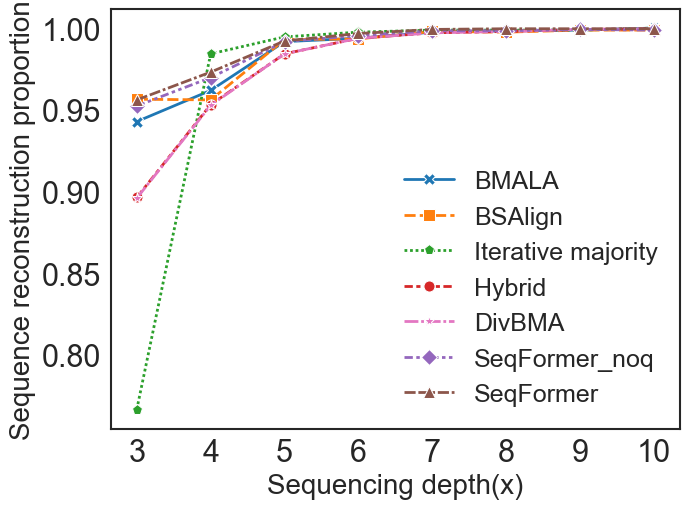

In [9]:
import seaborn as sns
import matplotlib.pyplot as plt

# ================================
# 📌 统一样式配置区域（你只改这里就行）
# ================================
XTICK_SIZE = 22
YTICK_SIZE = 22
XLABEL_SIZE = 20
YLABEL_SIZE = 20
LEGEND_SIZE = 18
LEGEND_TITLE = 20   # 如果有 title
SPINE_WIDTH  = 1.5

sns.set_style("white")
custom_colors = {
    "BMALA": "#1f77b4",              # 灰
    "BSAlign": "#ff7f0e",            # 深灰
    "Iterative majority": "#2ca02c", # 浅蓝
    "Hybrid": "#d62728", 
    "DivBMA":"#e377c2",# 蓝
    "SeqFormer_noq": "#9467bd",   # 绿
    "SeqFormer": "#8c564b",     # 红（重点突出）
}
# ================================
# 绘图
# ================================

plt.figure(figsize=(7, 5.2))

order = ["BMALA", "BSAlign", "Iterative majority", "Hybrid", "DivBMA","SeqFormer_noq","SeqFormer" ]

ax = sns.lineplot(
    x='depth',
    y='success_rate',
    hue="method",
    style="method",
    markers=["X", "s", "p", "o",'*', "D", "^"],   # 和顺序一一对应
    markersize=8,
    lw=2,
    data=result_df,
    hue_order=order,
    style_order=order,palette=custom_colors,
)

# ================================
# 坐标轴字体
# ================================
ax.set_xlabel('Sequencing depth(x)', fontsize=XLABEL_SIZE)
ax.set_ylabel('Sequence reconstruction proportion', fontsize=YLABEL_SIZE)

ax.tick_params(axis='x', labelsize=XTICK_SIZE)
ax.tick_params(axis='y', labelsize=YTICK_SIZE)
plt.xticks(range(3, 11))
# ================================
# 坐标轴线条加粗
# ================================
for side in ("top", "right", "left", "bottom"):
    ax.spines[side].set_visible(True)
    ax.spines[side].set_linewidth(1.5)

# ================================
# Legend：单独区域（在图外右侧）
# ================================
legend = ax.legend(
    prop={'size': LEGEND_SIZE},
    loc='best',            # 锚点
   
    frameon=False
)

# 如果需要 legend title（如 "Method"）
# legend.set_title("Method", prop={'size': LEGEND_TITLE})

# ================================
# 布局 + 保存
# ================================
# plt.tight_layout(rect=[0, 0, 0.85, 1])  
# rect=[left, bottom, right, top] 右侧预留 15% 空间放 legend
plt.tight_layout()
plt.savefig("second_shaohui1.png", dpi=600,bbox_inches='tight')
plt.show()
